In [40]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [41]:
data = pd.read_csv('../../data/processed_files/patient_timeseries_v4.csv')
data['stay_id'] = data['stay_id'].astype(int)
data

,timestep,stay_id,timestamp,gender,age,charlson_comorbidity_index,re_admission,los,morta_hosp,morta_90,...,sofa_resp,sofa_coag,sofa_liver,sofa_cv,sofa_cns,sofa_renal,sofa_score,sirs_score,septic_shock,sepsis
0,1,30000484,5.239603e+09,0,92.0,7,0,2.478889,0.0,1.0,...,1,0,1,0,2,0,4,3,0,1
1,2,30000484,5.239618e+09,0,92.0,7,0,2.478889,0.0,1.0,...,1,0,0,0,0,2,3,2,0,2
2,3,30000484,5.239632e+09,0,92.0,7,0,2.478889,0.0,1.0,...,4,0,0,2,0,2,8,1,0,2
3,4,30000484,5.239646e+09,0,92.0,7,0,2.478889,0.0,1.0,...,4,0,0,2,0,1,7,2,0,2
4,5,30000484,5.239661e+09,0,92.0,7,0,2.478889,0.0,1.0,...,3,0,0,2,0,1,6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572952,15,39999172,6.789132e+09,0,89.0,6,0,2.100775,0.0,0.0,...,2,0,2,0,1,1,6,2,0,2
572953,16,39999172,6.789146e+09,0,89.0,6,0,2.100775,0.0,0.0,...,2,0,2,0,1,1,6,2,0,2
572954,17,39999172,6.789160e+09,0,89.0,6,0,2.100775,0.0,0.0,...,0,0,2,0,0,1,3,1,0,2
572955,1,39999230,5.607382e+09,0,49.0,3,0,8.807431,0.0,0.0,...,1,1,2,0,0,0,4,2,0,1


In [15]:
data.columns

Index(['timestep', 'stay_id', 'timestamp', 'gender', 'age',
       'charlson_comorbidity_index', 're_admission', 'los', 'morta_hosp',
       'morta_90', 'fluid_total', 'fluid_step', 'uo_total', 'uo_step',
       'balance', 'vaso_median', 'vaso_max', 'abx_given',
       'hours_since_first_abx', 'num_abx', 'albumin', 'alt',
       'arterial_base_excess', 'arterial_co2_pressure', 'arterial_o2_pressure',
       'ast', 'bilirubin_direct', 'bilirubin_total', 'calcium_ionized',
       'calcium_non_ionized', 'calcium_total', 'chloride', 'creatinine',
       'dbp_arterial', 'fio2', 'gcs', 'glucose', 'hco3', 'heart_rate',
       'height_cm', 'height_inch', 'hematocrit', 'hemoglobin', 'inr',
       'lactate', 'lactic_acid', 'magnesium', 'map', 'mean_airway_pressure',
       'minute_volume', 'oxygen_flow', 'oxygen_flow_device',
       'peak_inspiratory_pressure', 'peep', 'ph_arterial', 'platelets',
       'potassium', 'pt', 'ptt', 'red_blood_cells', 'respiratory_rate',
       'richmond_ras', 'sbp_

In [42]:
len(data.groupby(['stay_id']))

35689

In [17]:
single_stay_id = data.drop_duplicates(subset='stay_id')

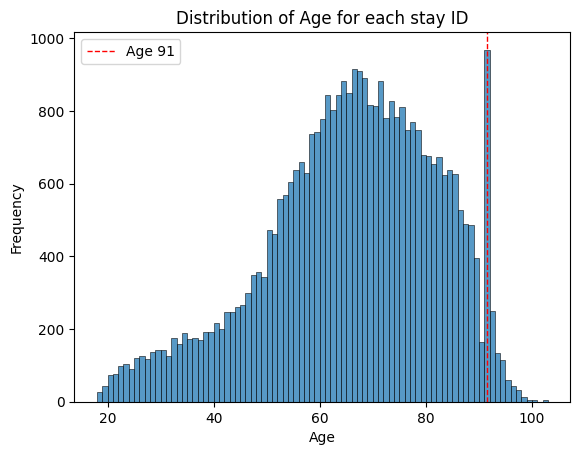

In [38]:
sns.histplot(data = single_stay_id, x='age', bins=len(single_stay_id['age'].unique()))
plt.axvline(x=91.5, color='red', linestyle='--', linewidth=1, label='Age 91')
plt.legend()
plt.title('Distribution of Age for each stay ID')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


# reason for the spike at age 91
- in the MIMIC-IV dataset, patients with age>91, are recorded as age 91
- in MIMIC, the patients record dates are also offest by a random amount of years
- each patient has an anchor_year, which is a shifted year corrsponding to a specific reference point in the patients record
- anchor_age is the age of the patient at the anchor_year
- In the demog.py script, if the patient is readmitted after the anchor_year, the patients new age is calculated as anchor_age + (admission_year - anchor_year)
- So if a patient is 91 at the achor_year, they will have some new admittance age >= 91
- In conclusion: 
    - the spike at 91 is due to the deintification process in MIMIC-IV
    - the tail after 91, is due to patients who are >= 91 (but saved as 91 due to deidentification) at the anchor_year, and are readmitted after the anchor_year, and so have a new age for the new admittance saved as a value >= 91

I believe the best way to deal with this is to set all the patients > 91 to 91, and add a flag for patients with age 91

I do this below

In [39]:
data[data['age'] > 91] = 91
print(data['age'].max())

91.0


# timestep of sepsis onset
- below we see a histogram of timesteps where sepsis onset occurs (i.e. where sepsis == 1)
- we see a huge spike at timestep 1, and then an exponential decrease in the number of sepsis onsets as the timestep increases


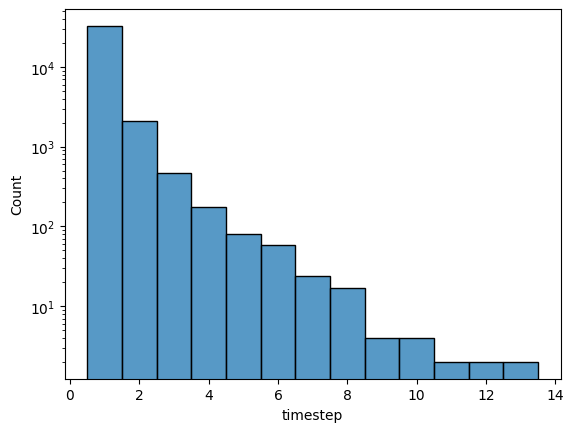

In [29]:
sns.histplot(data = data[data['sepsis'] == 1], x='timestep', discrete=True)
plt.yscale('log')

<Axes: xlabel='timestep', ylabel='Count'>

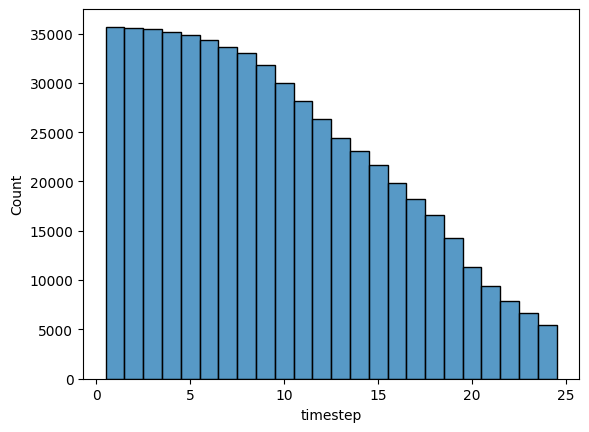

In [ ]:
# maybe the reason for the large number of sepsis onset at timestep 1 is as 
# the data collection started at the time of sepsis/infection onset, and so is a lot likelier to be 
# earlier on.
# i.e. we take data from 24hrs before infection onset, but a lot of patients may only have 4 hours or less of data before
# infection onset (i.e. data collection started at the time of infection onset).

sns.histplot(data = data, x='timestep', discrete=True)
plt.yscale('log')

two possible prediction tasks:
    - 'will this person have sepsis in the next x hours'
    - 'will this person have sepsis at any point in their stay'